In [29]:
import numpy as np 
import matplotlib.pylab as plt
import pandas as pd

In [30]:
import pandas as pd

url = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?"
    "query=select+"
    "pl_name,"
    "pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,"
    "pl_rade,pl_radeerr1,pl_radeerr2,"
    "pl_orbper,st_spectype,sy_jmag,"
    "st_mass,st_masserr1,st_masserr2"
    "+from+ps&format=csv"
)

df = pd.read_csv(url)

# --- Select M-dwarf hosts ---
mask_mdwarf = df['st_spectype'].fillna("").str.startswith('M')
df_md = df.loc[mask_mdwarf].copy()

print(f"Planets around M-dwarf host stars: {len(df_md)}")

# -------------------------------------------------------------------
# Mass–radius relation (Earth masses)
# -------------------------------------------------------------------
def mass_from_radius(r):
    if r < 1.5:
        return (r/1.03)**(1/0.27)
    else:
        return (r/0.56)**(1/0.67)

# -------------------------------------------------------------------
# 1) DataFrame with MEASURED masses only
# -------------------------------------------------------------------
df_measured = df_md.loc[
    (~df_md['pl_bmasse'].isna()) & (~df_md['pl_bmasseerr1'].isna()) &
    (~df_md['pl_orbper'].isna())
].copy()

df_measured['mass'] = df_measured['pl_bmasse']

# -------------------------------------------------------------------
# 2) DataFrame with INFERRED masses from radius
#    (only where mass is missing but radius exists)
# -------------------------------------------------------------------
df_radius_mass = df_md.loc[
    (df_md['pl_bmasseerr1'].isna()) &
    (~df_md['pl_orbper'].isna())
].copy()

df_radius_mass['mass'] = df_radius_mass['pl_rade'].apply(mass_from_radius)

# -------------------------------------------------------------------
# 3) DataFrame to plot: ONLY measured masses
# -------------------------------------------------------------------
df_to_plot = df_measured.copy()

# Mass cuts (in Earth masses)
df_to_plot = df_to_plot[
    (df_to_plot['mass'] < 0.8 * 317) &
    (df_to_plot['mass'] > 0.005 * 317)
]

# Period cut
df_to_plot = df_to_plot[df_to_plot['pl_orbper'] < 1e4]

# Remove duplicates
df_to_plot = df_to_plot.drop_duplicates(subset='pl_name', keep='first')

print(f"Number of M-dwarf planets with measured mass and period: {len(df_to_plot)}")
print(f"Number with inferred mass from radius: {len(df_radius_mass)}")


Planets around M-dwarf host stars: 661
Number of M-dwarf planets with measured mass and period: 191
Number with inferred mass from radius: 295


In [31]:
# Load results CSV
data = pd.read_csv("final_barnards_results_summary_s10.csv")
data['snr'] = 10
for i in ['25','50','75']:
    df = pd.read_csv("final_barnards_results_summary_s"+i+".csv")
    df['snr'] = float(i)
    data = pd.concat([data,df])

data = data[data['Mp_jupiter']<0.2]
# Compute 1-sigma uncertainty estimate
data["K_sigma"] = (data["K_plus"] + data["K_minus"]) / 2

# Compute Z-score per realization
data["Z_score"] = (data["K_median"] - data["K_true"]) / data["K_sigma"]
data['Squared_error'] = (data["K_median"] - data["K_true"])**2
data['Absolute_error'] = np.abs(data["K_median"] - data["K_true"])
data = data.sort_values(by=["snr", "Mp_jupiter"], ascending=[True, True])

In [32]:
dk_snr75 = np.mean(data[(data['snr']==75)&(data['method']=='mala')]['K_sigma'])
dk_snr50 = np.mean(data[(data['snr']==50)&(data['method']=='mala')]['K_sigma'])
dk_snr25 = np.mean(data[(data['snr']==25)&(data['method']=='mala')]['K_sigma'])
dk_snr10 = np.mean(data[(data['snr']==10)&(data['method']=='mala')]['K_sigma'])

dks = np.array([dk_snr10,dk_snr25,dk_snr50,dk_snr75])

In [33]:
dks

array([4.48228526, 1.75727594, 0.8762949 , 0.57879889])

In [34]:
# Convert to numeric (mass may be in Jupiter masses, period in days — confirm if needed)
df_to_plot['mass'] = pd.to_numeric(df_to_plot['mass'], errors='coerce')
df_to_plot['pl_orbper'] = pd.to_numeric(df_to_plot['pl_orbper'], errors='coerce')
df_radius_mass['mass'] = pd.to_numeric(df_radius_mass['mass'], errors='coerce')
df_radius_mass['pl_orbper'] = pd.to_numeric(df_radius_mass['pl_orbper'], errors='coerce')

In [35]:
def get_K(P_days, Mp_jupiter, Ms_solar):
    return 28.4 * ((P_days / 365.2422) ** (-1/3)) * Mp_jupiter * (Ms_solar ** (-2/3))

df_to_plot['kamp'] = df_to_plot.apply(
    lambda row: get_K(row["pl_orbper"], row["mass"]/317, row["st_mass"]),
    axis=1
)

df_radius_mass['kamp'] = df_radius_mass.apply(
    lambda row: get_K(row["pl_orbper"], row["mass"]/317, row["st_mass"]),
    axis=1
)

In [36]:
real_mass_sup_Earth = df_to_plot[df_to_plot['pl_rade']<1.6]
real_mass_big = df_to_plot[df_to_plot['pl_rade']>1.6]

pred_mass_sup_Earth = df_radius_mass[df_radius_mass['pl_rade']<1.6]
pred_mass_big = df_radius_mass[df_radius_mass['pl_rade']>1.6]

TOI-2136 b 9552    4.21322
Name: kamp, dtype: float64
TOI-1452 b 10571    3.500168
Name: kamp, dtype: float64
GJ 1289 b 16379    2.359597
Name: kamp, dtype: float64
TOI-1680 b Series([], Name: kamp, dtype: float64)
here


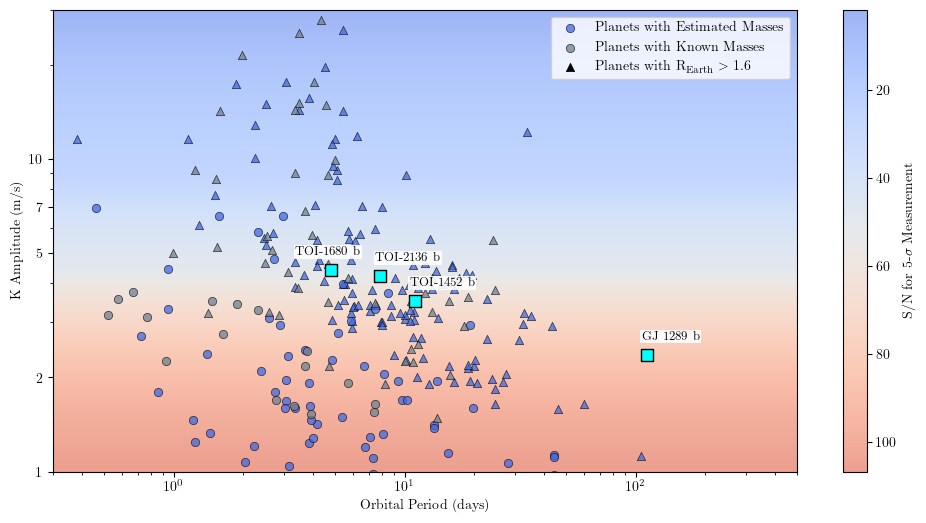

In [44]:
from scipy.interpolate import interp1d
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap

def truncate_colormap(cmap, minval=0.15, maxval=0.65, n=256):
    return LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n))
    )

# Original colormap
cmap = cm.coolwarm

# Truncated version (adjust numbers to taste)
cmap_trunc = truncate_colormap(cmap, 0.15, 0.85)

fig, ax = plt.subplots(figsize=(12,6))

# Example data points: (K amplitude, SNR)

SNR_points = np.array([10, 25, 50, 75])

# Create an interpolation function
interp = interp1d(dks*5, SNR_points, kind='linear', fill_value='extrapolate')

# Create a K grid for the y-axis
K_grid = np.linspace(1, 30, 500)  # slightly beyond the min/max
SNR_grid = interp(K_grid)

# Create a 2D array to fill the whole x-axis
period_min, period_max = 3e-1, 5e2
P_grid = np.linspace(period_min, period_max, 2)  # only 2 points needed for width
SNR_2D = np.tile(SNR_grid[:, None], (1, len(P_grid)))


# Plot the interpolated background
im = ax.imshow(
    SNR_2D,
    extent=[period_min, period_max, K_grid.min(), K_grid.max()],
    origin='lower',
    aspect='auto',
    cmap=cmap_trunc,
    alpha=0.65
)

ax.scatter(pred_mass_big['pl_orbper'], pred_mass_big['kamp'],color = "royalblue",#1E90FF",##1f77b4" ,   # muted blue
marker = "^",
alpha = 0.75,
edgecolor = "k",
linewidth = 0.5)#c="b",alpha=0.35)
ax.scatter(pred_mass_sup_Earth['pl_orbper'], pred_mass_sup_Earth['kamp'],color = "royalblue",#1E90FF",##1f77b4" ,   # muted blue
marker = "o",
alpha = 0.75,
edgecolor = "k",
linewidth = 0.5,label="Planets with Estimated Masses")#c="b",alpha=0.35)


ax.scatter(real_mass_big['pl_orbper'], real_mass_big['kamp'],color = "#708090", #ff7f0e" ,   # muted orange
marker = "^",
alpha = 0.75,
edgecolor = "k",
linewidth = 0.5)
ax.scatter(real_mass_sup_Earth['pl_orbper'], real_mass_sup_Earth['kamp'],color = "#708090", #ff7f0e" ,   # muted orange
marker = "o",
alpha = 0.75,
edgecolor = "k",
linewidth = 0.5, label="Planets with Known Masses"
)


ax.scatter(-0.1, 10,color = "k",#1E90FF",##1f77b4" ,   # muted blue
marker = "^",
alpha = 1,
edgecolor = "k",
linewidth = 0.5,label="Planets with R$_{\mathrm{Earth}}>1.6$")#c="b",alpha=0.35)

# Add individual planets
planets = ['TOI-2136 b','TOI-1452 b','GJ 1289 b','TOI-1680 b']
for name in planets:
    info = df_to_plot[df_to_plot['pl_name']==name]
    print(name,info['kamp'])
    if info.empty: 
        print("here")
        info = df_radius_mass[df_radius_mass['pl_name']==name]
    ax.scatter(info['pl_orbper'], info['kamp'], c='#00FFFF', s=75, zorder=5,marker="s",edgecolor="k")
    if name =='TOI-1680 b':
        ax.text(
        info['pl_orbper']-3*(info['pl_orbper']/10), info['kamp']+1*(info['kamp']/10), name,
        color='black',
        fontsize=9,
        ha='left', va='bottom',
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=1),
        zorder=6)
    else:
        ax.text(
            info['pl_orbper']-0.5*(info['pl_orbper']/10), info['kamp']+1*(info['kamp']/10), name,
            color='black',
            fontsize=9,
            ha='left', va='bottom',
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=1),
            zorder=6
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(3e-1,5e2)
ax.set_ylim(1,30)
ax.set_xlabel('Orbital Period (days)')
ax.set_ylabel("K Amplitude (m/s)")

# 1. Define tick positions
ax.set_yticks([1,2,5,7,10])

# 2. Set custom labels
ax.set_yticklabels(['1','2','5','7','10'])

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("S/N for $5$-$\sigma$ Measurement")
cbar.ax.invert_yaxis()
plt.legend()
plt.savefig("sensitivity.pdf",dpi=300)
plt.show()
# ax.set_ylabel('Planet Mass (M$_{\mathrm{Earth}}$)')

TOI-2136 b
TOI-1452 b
GJ 1289 b
TOI-1680 b
here


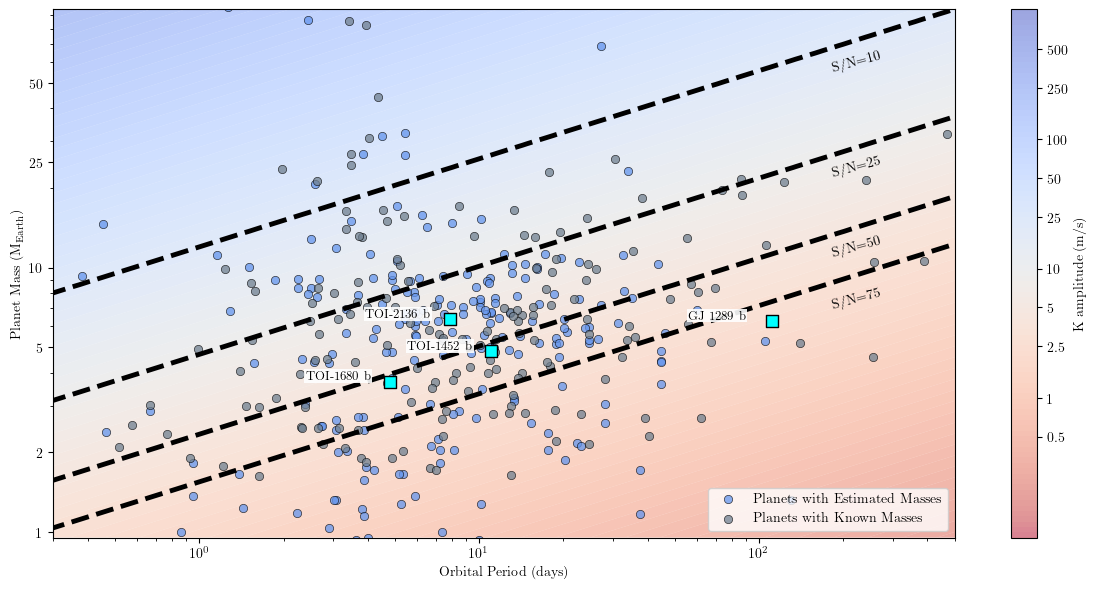

In [38]:



# Drop rows that failed numeric conversion
df_to_plot = df_to_plot.dropna(subset=['mass', 'pl_orbper'])

# Query: you might want to convert units (e.g. from Jupiter masses to Earth masses), but I'll leave as given


planets = ['TOI-2136 b','TOI-1452 b','GJ 1289 b','TOI-1680 b']
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})
def get_K(P_days, Mp_jupiter, Ms_solar):
    return 28.4 * ((P_days / 365.2422) ** (-1/3)) * Mp_jupiter * (Ms_solar ** (-2/3))

# Grid
P = np.logspace(-1, 4, 100)  # days
Mp = np.linspace(0.003, 0.8, 100)*317 # Jupiter masses
Ks = get_K(P[np.newaxis, :], Mp[:, np.newaxis]/317, 0.2)

# Create figure
fig, ax = plt.subplots(figsize=(12,6))
P_grid, Mp_grid = np.meshgrid(P, Mp)

# Make levels logarithmic but biased toward smaller values
num_levels = 100
levels = np.logspace(np.log10(Ks.min()), np.log10(Ks.max()), num_levels)

# Filled contour
cf = ax.contourf(
    P_grid,
    Mp_grid,
    Ks,
    levels=levels,
    cmap='coolwarm_r',
    norm=LogNorm(vmin=Ks.min(), vmax=Ks.max()),alpha=0.5, antialiased=True
)


ax.scatter(df_radius_mass['pl_orbper'], df_radius_mass['mass'],color = "cornflowerblue",#1E90FF",##1f77b4" ,   # muted blue
marker = "o",
alpha = 0.75,
edgecolor = "k",
linewidth = 0.5,label="Planets with Estimated Masses")#c="b",alpha=0.35)
ax.scatter(df_to_plot['pl_orbper'], df_to_plot['mass'],color = "#708090", #ff7f0e" ,   # muted orange
marker = "o",
alpha = 0.75,
edgecolor = "k",
linewidth = 0.5, label="Planets with Known Masses"
)#c="k",alpha=0.35,marker="s")

contour_levels = np.flip(dks*5)  # K values
P_grid, Mp_grid = np.meshgrid(P, Mp)
cs = ax.contour(
    P_grid,
    Mp_grid,
    Ks,
    levels=contour_levels,
    colors='k',
    linewidths=3.5,
    linestyles="--"
)

# Add individual planets
for name in planets:
    print(name)
    info = df_to_plot[df_to_plot['pl_name']==name]
    if info.empty: 
        print("here")
        info = df_radius_mass[df_radius_mass['pl_name']==name]
    ax.scatter(info['pl_orbper'], info['mass'], c='#00FFFF', s=75, zorder=5,marker="s",edgecolor="k")
    ax.text(
        info['pl_orbper']-5*info['pl_orbper']/10, info['mass'], name,
        color='black',
        fontsize=9,
        ha='left', va='bottom',
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=1),
        zorder=6
    )

ax.text(180, 55, "S/N=10", color='k', fontsize=10,rotation=15)
ax.text(180, 22, "S/N=25", color='k', fontsize=10,rotation=15)
ax.text(180, 11, "S/N=50", color='k', fontsize=10,rotation=15)
ax.text(180, 7, "S/N=75", color='k', fontsize=10,rotation=15)

# Axes
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Orbital Period (days)')
ax.set_ylabel('Planet Mass (M$_{\mathrm{Earth}}$)')
# ax.set_title('Sensitivity Plot')
ax.set_xlim(3e-1,5e2)
ax.set_ylim(0.003*317,0.3*317)
yticks = np.array([1,2,5,10,25,50])
ax.set_yticks(yticks)
ax.set_yticklabels([str(y) for y in yticks]) 

# Colorbar
# Example: set ticks manually
cbar = plt.colorbar(cf, ax=ax)

# Define specific K values for ticks
tick_values = [0.5,1,2.5,5,10,25,50,100,250,500]  # whatever makes sense for your K range

# Apply LogNorm correctly
cbar.set_ticks(tick_values)          # set tick locations
cbar.set_ticklabels([str(v) for v in tick_values])  # set labels

cbar.set_label('K amplitude (m/s)')

plt.legend(loc="lower right")
plt.tight_layout()
# plt.savefig("sensitivity.pdf",dpi=300)
plt.show()

In [39]:
df_radius_mass[df_radius_mass['pl_name']=='TOI-1680 b']

,pl_name,pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_rade,pl_radeerr1,pl_radeerr2,pl_orbper,st_spectype,sy_jmag,st_mass,st_masserr1,st_masserr2,mass,kamp
10713,TOI-1680 b,NaN,NaN,NaN,1.466,0.063,-0.049,4.802634,M4.5+/-0.5,11.637,0.1798,0.0044,-0.0044,3.696287,4.404184


In [40]:
df_to_plot[df_to_plot['pl_name']=='GJ 1289 b']

,pl_name,pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_rade,pl_radeerr1,pl_radeerr2,pl_orbper,st_spectype,sy_jmag,st_mass,st_masserr1,st_masserr2,mass,kamp
16379,GJ 1289 b,6.27,1.23,-1.25,NaN,NaN,NaN,111.74,M4.5 Ve,8.11,0.21,0.02,-0.02,6.27,2.359597


In [41]:
6.2/1.2

5.166666666666667

In [42]:
mask_mdwarf2 = df_md['st_spectype'].fillna("").str.startswith('M4')
ha = df_md[mask_mdwarf2].drop_duplicates(subset='pl_name', keep='first')
ha['mass'] = ha['pl_rade'].apply(mass_from_radius)
ha = ha[
    (ha['mass'] < 10) &
    (ha['mass'] > 2)
]
ha

,pl_name,pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_rade,pl_radeerr1,pl_radeerr2,pl_orbper,st_spectype,sy_jmag,st_mass,st_masserr1,st_masserr2,mass
859,K2-384 f,NaN,NaN,NaN,2.222,0.091,-0.082,13.627490,M4 V,12.118000,0.3300,0.0090,-0.0090,7.822890
860,K2-384 d,NaN,NaN,NaN,1.392,0.118,-0.075,6.679582,M4 V,12.118000,0.3300,0.0090,-0.0090,3.051068
864,K2-384 e,NaN,NaN,NaN,1.345,0.139,-0.082,9.715043,M4 V,12.118000,0.3300,0.0090,-0.0090,2.686606
5045,Kepler-445 d,NaN,NaN,NaN,1.250,0.190,-0.190,8.152750,M4,13.542000,0.1800,0.0400,-0.0400,2.048239
6421,LHS 1140 b,5.60,0.19,-0.19,1.730,0.025,-0.025,24.737230,M4.5 V,9.612001,0.1844,0.0045,-0.0045,5.384327
7208,LHS 1140 c,1.91,0.06,-0.06,1.272,0.026,-0.026,3.777940,M4.5 V,9.612001,0.1844,0.0045,-0.0045,2.184963
8174,LTT 3780 b,2.62,0.48,-0.46,1.332,0.072,-0.075,0.768448,M4 V,9.007000,0.4010,0.0120,-0.0120,2.591681
8539,TOI-237 b,NaN,NaN,NaN,1.440,0.120,-0.120,5.436098,M4.5 V,11.740000,0.1790,0.0040,-0.0040,3.459254
9552,TOI-2136 b,6.37,2.45,-2.29,2.190,0.170,-0.170,7.851928,M4.5 V,10.184000,0.3400,0.0200,-0.0200,7.655337
10094,TOI-715 b,NaN,NaN,NaN,1.550,0.064,-0.064,19.288004,M4,11.808000,0.2250,0.0120,-0.0120,4.569997
